<a href="https://colab.research.google.com/github/kylalacorte/CPE018/blob/main/LACORTE_Activity_5_Line_and_Circle_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY NO.** | **Activity 5. Line and Circle Detection**
**Name** | LACORTE, KYLA ANDREA R.
**Section** | CPE31S2
**Date Performed**: | JANUARY 20, 2026
**Date Submitted**: | JANUARY 20, 2026
**Instructor**: | ENGR. MARIA RIZETTE H. SAYO

<hr>

## 1. Objectives

This activity aims to introduce students to openCV's APIs for Hough Transform.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize openCV for circle and line detection.
* Analyze the use of hough Line and Circle function for finding objects in an image.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Procedures and Outputs

Detecting edges and contours are not only common and important tasks, they also constitute the basis for other complex operations. Lines and shape detection go hand in hand with edge and contour detection, so let's examine how OpenCV implements these.

### Line Detection

The theory behind lines and shape detection has its foundation in a technique called the Hough transform, invented by Richard Duda and Peter Hart, who extended (generalized) the work done by Paul Hough in the early 1960s.

Let's take a look at OpenCV's API for the Hough transforms.

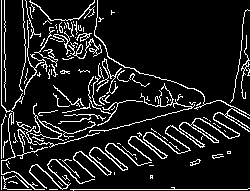

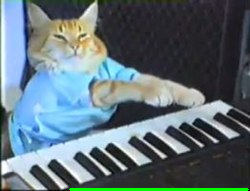

In [ ]:
# Image source: https://en.wikipedia.org/wiki/Keyboard_Cat

from google.colab.patches import cv2_imshow
import cv2
import numpy as np

img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/Keyboard_cat.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,120)
minLineLength = 20
maxLineGap = 5
lines = cv2.HoughLinesP(edges,1,np.pi/180,100,minLineLength,
        maxLineGap)
for x1,y1,x2,y2 in lines[0]:
  cv2.line(img,(x1,y1),(x2,y2),(0,255,0),2)

cv2_imshow(edges)
cv2_imshow(img)

The crucial point of this simple script —aside from the HoughLines function call— is the setting of minimum line length (shorter lines will be discarded) and the maximum line gap, which is the maximum size of a gap in a line before the two segments start being considered as separate lines.

Also note that the HoughLines function takes a single channel binary image, processed through the Canny edge detection filter. Canny is not a strict requirement, however; an image that's been denoised and only represents edges, is the ideal source for a Hough transform, so you will find this to be a common practice.

The parameters of HoughLinesP are as follows:
- The image we want to process.
- The geometrical representations of the lines, rho and theta, which are usually 1 and np.pi/180.
- The threshold, which represents the threshold below which a line is discarded. The Hough transform works with a system of bins and votes, with each bin representing a line, so any line with a minimum of the <threshold> votes is retained, the rest discarded.
- MinLineLength and MaxLineGap, which we mentioned previously

**Questions:**

1. Which line of code is responsible for setting the minimum line length?
minLineLength=20
This line controls how short a detected line can be. Shorter lines than this value are ignored.

2. What is the mathematical formula for Hough transform and explain how it finds lines.

The formula is p=xcos()+ysin()

### Circle Detection

OpenCV also has a function for detecting circles, called HoughCircles. It works in a very similar fashion to HoughLines, but where minLineLength and maxLineGap were the parameters to discard or retain lines, HoughCircles has a minimum distance between circles' centers, minimum, and maximum radius of the circles. Here's the obligatory example:

Before going into the sample code, check first: **What is the HoughCircles function and what are its parameters?**

**ANSWER**
It is a function in OpenCV used to detect circular objects in an image. It works by analyzing edge patterns and finding points that form a circle. Its main parameters control how detailed the detection is, such as how sensitive the detection should be, how far apart detected circles must be, and the minimum and maximum size of circles to look for.

In [ ]:
import cv2
import numpy as np

# Our testing value
n = 15

planets = cv2.imread('/content/drive/MyDrive/Colab Notebooks/eart.png')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n) # We will change this value passed as parameter and observe results
cimg = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
circles = cv2.HoughCircles(img,cv2.HOUGH_GRADIENT,1,120,
                            param1=100,param2=30,minRadius=0,
                                maxRadius=0)
circles = np.uint16(np.around(circles))

for i in circles[0,:]:
  # draw the outer circle
  cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
  # draw the center of the circle
  cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2.imwrite("planets_circles.png", planets)
cv2_imshow(planets)

What happens to the code once you run **and the value of n is 5**?

When the value of n is set to 5, the image is slightly smoothed using a median blur. This reduces small noise while keeping the coin edges clear. As a result, the circles are detected more accurately without losing important details.

Change the value to 9, **what happens to the image**?

When n is changed to 9, the image becomes more blurred. Noise is further reduced, but some fine details and sharp edges start to fade. Circle detection still works, but the edges of the coins are less sharp than before.

Lastly, change the value to 15, **what can you say about the resulting image?**

With n set to 15, the image becomes heavily blurred. While most noise is removed, important details such as clear coin boundaries are also lost. This can cause the circle detector to miss some coins or detect them less accurately.

Provide an analysis of the output so far. How does the code help the changes in the resulting image?

The code uses median blurring to control noise before detecting circles. Lower blur values keep details sharp but may include noise, while higher values reduce noise but remove important features. By adjusting the blur value, the code balances clarity and smoothness, which directly affects how accurately the circles are detected. Choosing the right value improves detection and produces cleaner results.

## 4. Supplementary Activity

The attached image contains coins used in the Philippines.

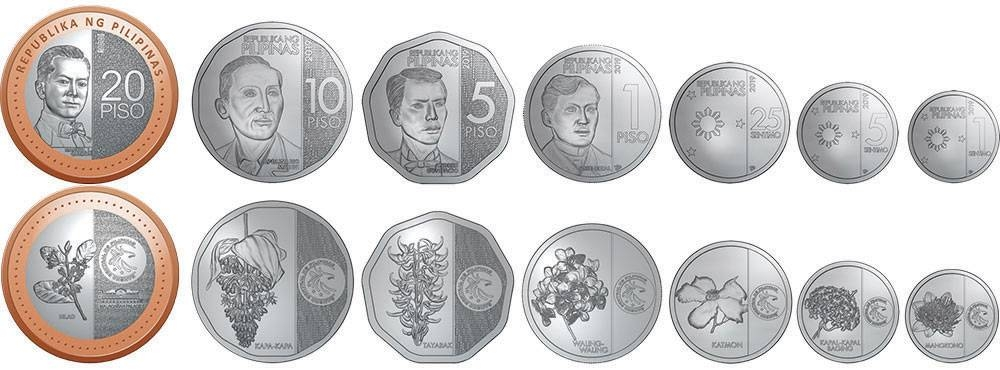

Your job is to count the amount of coins (denomation not included, no sum of prices; just the amount of coins present) through either line detection or circle detection.

- Create a function using line detection and pass this image as parameter, what is the output? Can you use houghlines to count circles?
- Create a function using circle detection and pass this image as parameter, show the output? Can you use houghcircles to count the circles?

**LINE DETECTION**

The image shows many random straight lines detected across the coins and background, but it does not correctly identify or count the coins.

In [ ]:
import cv2
import numpy as np

# Testing value (reduced)
n = 9

planets = cv2.imread('/content/drive/MyDrive/Colab Notebooks/eart.png')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)

# Controlled blur
img = cv2.medianBlur(gray_img, n)

cimg = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

circles = cv2.HoughCircles(
    img,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,        # prevents multiple detections
    param1=120,
    param2=40,          # stricter detection
    minRadius=50,       # limit circle size
    maxRadius=120
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(planets, (i[0], i[1]), i[2], (0, 255, 0), 2)
        cv2.circle(planets, (i[0], i[1]), 2, (0, 0, 255), 3)

cv2.imshow(planets)

**Can you use HoughLines to count circles?**

No. Line detection is not suitable for counting coins because coins are circular objects. HoughLines only detects straight edges and produces noisy results that cannot represent circles accurately.

**CIRCLE DETECTION**

Each coin is clearly outlined with a green circle and its center marked. The printed number represents the total number of coins detected in the image.

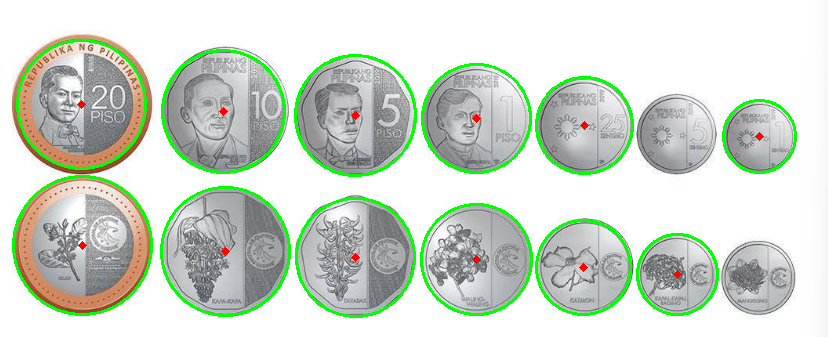

Total coins detected: 12


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

coins = cv2.imread('/content/drive/MyDrive/Colab Notebooks/coins.png')

gray = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=90,
    param1=120,
    param2=45,
    minRadius=35,
    maxRadius=80
)

coin_count = 0

if circles is not None:
    circles = np.uint16(np.around(circles))
    coin_count = len(circles[0])

    for (x, y, r) in circles[0]:
        cv2.circle(coins, (x, y), r, (0, 255, 0), 2)
        cv2.circle(coins, (x, y), 2, (0, 0, 255), 3)

cv2_imshow(coins)
print("Total coins detected:", coin_count)

**Can you use HoughCircles to count circles?**

Yes. HoughCircles is designed to detect circular shapes. It accurately identifies each coin and allows us to count them by simply counting the detected circles.

## 5. Summary, Conclusions and Lessons Learned

This activity shows that reducing noise in an image helps detect circles more accurately. A small amount of blurring removes unwanted details while keeping the shape of the coins clear. Too much blurring makes the image unclear and affects detection. Choosing the right settings leads to cleaner images and more accurate results.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*